<a href="https://colab.research.google.com/github/adritoo23-prog/BIT2/blob/main/Entregable_4_Data_science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Parte 1 – Comprensión del problema

    
Identifica la variable objetivo (target)
Responde:
  ○ ¿Es un problema de clasificación o regresión?
  ○ ¿Por qué?
Describe brevemente el contexto del problema


In [83]:
#importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [84]:
from google.colab import files
uploaded =files.upload()

Saving test_Y3wMUE5_7gLdaTN.csv to test_Y3wMUE5_7gLdaTN (2).csv


Este archivo de predicción de aprobación de prestamo es un problema de clasificación ya que las etiquetas son entre Si /No como respuesta de aprobación de un crédito

Y la clasificación se basa en unas etiquetas o categorias definidas

Parte 2 – Exploración de datos (EDA básica)

In [85]:
df= pd.read_csv('/content/test_Y3wMUE5_7gLdaTN.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [86]:
df.shape

(367, 12)

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [88]:
#valores nulos
df.isnull().sum()

,0
Loan_ID,0
Gender,11
Married,0
Dependents,10
Education,0
Self_Employed,23
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6


In [89]:
#Eliminar nulos de variable objetivo

df.dropna(subset=["Credit_History"], inplace=True)
df.shape

(338, 12)

In [90]:
df.isnull().sum()

,0
Loan_ID,0
Gender,11
Married,0
Dependents,8
Education,0
Self_Employed,22
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,5


In [91]:
#Se Analiza la distribución de la variable objetivo.
print(df["Credit_History"].value_counts())

Credit_History
1.0    279
0.0     59
Name: count, dtype: int64


In [92]:
from sklearn.linear_model import LogisticRegression

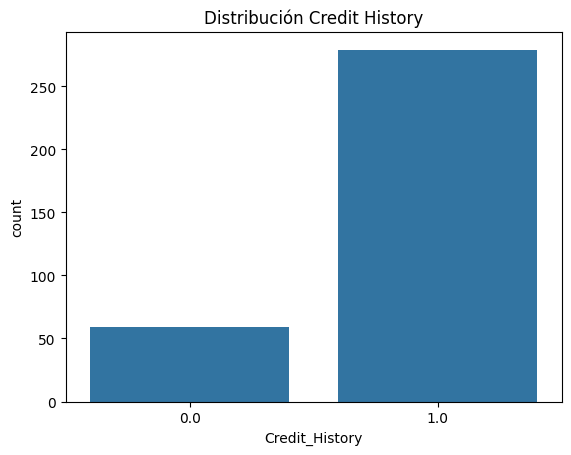

In [93]:
# visualización de las diferentes categorias que hay, estan codificados por eso es 0,1
sns.countplot(x='Credit_History', data=df)
plt.title('Distribución Credit History')
plt.show()

In [94]:
#Se elimina
df = df.drop(columns=['Loan_ID'])

In [95]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5720,0,110.0,360.0,1.0,True,True,False,False,False,False,False,False,True
1,3076,1500,126.0,360.0,1.0,True,True,True,False,False,False,False,False,True
2,5000,1800,208.0,360.0,1.0,True,True,False,True,False,False,False,False,True
4,3276,0,78.0,360.0,1.0,True,False,False,False,False,True,False,False,True
5,2165,3422,152.0,360.0,1.0,True,True,False,False,False,True,True,False,True


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 338 entries, 0 to 366
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ApplicantIncome          338 non-null    int64  
 1   CoapplicantIncome        338 non-null    int64  
 2   LoanAmount               333 non-null    float64
 3   Loan_Amount_Term         333 non-null    float64
 4   Credit_History           338 non-null    float64
 5   Gender_Male              338 non-null    bool   
 6   Married_Yes              338 non-null    bool   
 7   Dependents_1             338 non-null    bool   
 8   Dependents_2             338 non-null    bool   
 9   Dependents_3+            338 non-null    bool   
 10  Education_Not Graduate   338 non-null    bool   
 11  Self_Employed_Yes        338 non-null    bool   
 12  Property_Area_Semiurban  338 non-null    bool   
 13  Property_Area_Urban      338 non-null    bool   
dtypes: bool(9), float64(3), int64(2

In [103]:
#Validar Columnas Nulas
df.isnull().sum()

,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,5
Credit_History,0
Gender_Male,0
Married_Yes,0
Dependents_1,0
Dependents_2,0
Dependents_3+,0


In [104]:
df.dropna(subset=["LoanAmount"], inplace=True)
df.dropna(subset=["Loan_Amount_Term"], inplace=True)
df.shape

(328, 14)

In [105]:
# X: Conjunto de caracteristicas
X = df.drop('Credit_History', axis=1)

# y: Variable Objetivo
y = df['Credit_History']

# División en conjuntos de entrenamiento y prueba (usa stratify para respetar proporción de clases)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [106]:
display(X_train_scaled)

array([[ 0.62688699, -0.63178518,  0.16361496, ..., -0.33895961,
        -0.6929834 , -0.76673254],
       [-0.30394996,  0.72463173,  0.29114146, ..., -0.33895961,
         1.44303602, -0.76673254],
       [-0.31600795, -0.63178518, -1.25739456, ..., -0.33895961,
        -0.6929834 ,  1.30423576],
       ...,
       [-0.40654168,  0.03326883,  0.25470532, ..., -0.33895961,
        -0.6929834 , -0.76673254],
       [-0.26342723,  0.21613712, -0.01856574, ..., -0.33895961,
        -0.6929834 , -0.76673254],
       [ 0.18647401, -0.4420162 , -0.07321996, ..., -0.33895961,
         1.44303602, -0.76673254]])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression - Accuracy: 0.8485 | F1 Macro: 0.5417
              precision    recall  f1-score   support

         0.0       1.00      0.09      0.17        11
         1.0       0.85      1.00      0.92        55

    accuracy                           0.85        66
   macro avg       0.92      0.55      0.54        66
weighted avg       0.87      0.85      0.79        66



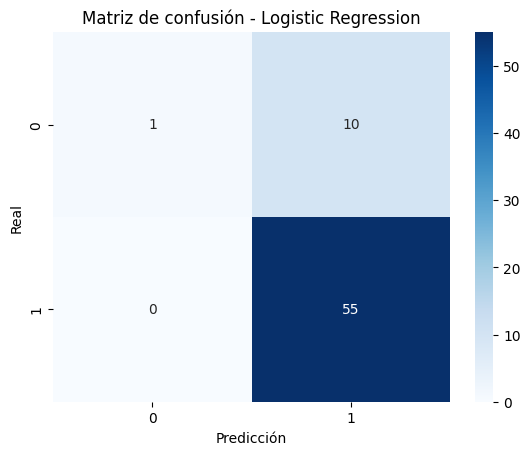


KNN - Accuracy: 0.8333 | F1 Macro: 0.5307
              precision    recall  f1-score   support

         0.0       0.50      0.09      0.15        11
         1.0       0.84      0.98      0.91        55

    accuracy                           0.83        66
   macro avg       0.67      0.54      0.53        66
weighted avg       0.79      0.83      0.78        66



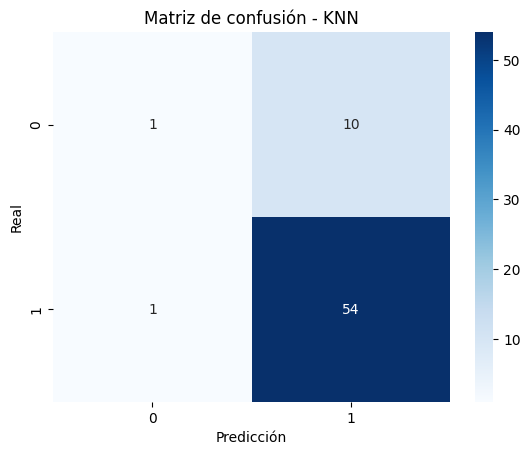


Decision Tree - Accuracy: 0.7273 | F1 Macro: 0.5417
              precision    recall  f1-score   support

         0.0       0.23      0.27      0.25        11
         1.0       0.85      0.82      0.83        55

    accuracy                           0.73        66
   macro avg       0.54      0.55      0.54        66
weighted avg       0.75      0.73      0.74        66



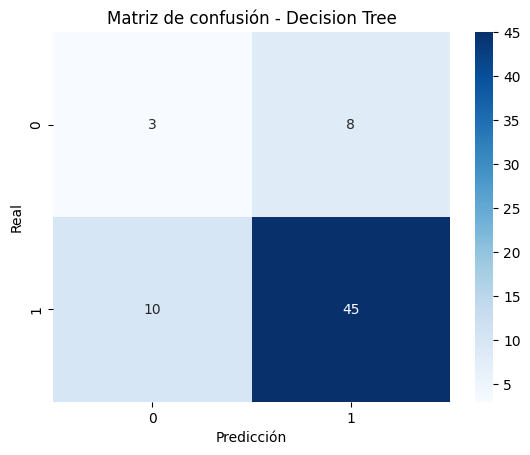


Random Forest - Accuracy: 0.8333 | F1 Macro: 0.5863
              precision    recall  f1-score   support

         0.0       0.50      0.18      0.27        11
         1.0       0.85      0.96      0.91        55

    accuracy                           0.83        66
   macro avg       0.68      0.57      0.59        66
weighted avg       0.80      0.83      0.80        66



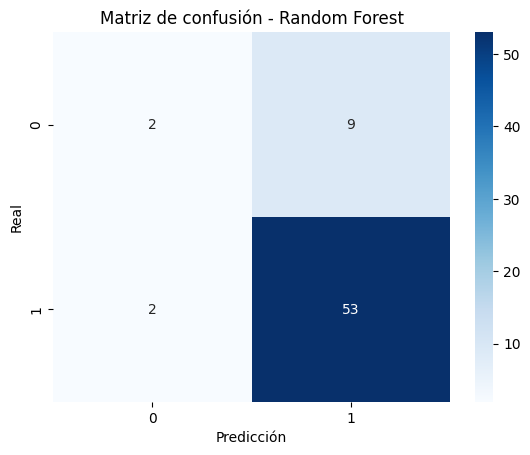


SVC (Linear) - Accuracy: 0.8333 | F1 Macro: 0.4545
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        11
         1.0       0.83      1.00      0.91        55

    accuracy                           0.83        66
   macro avg       0.42      0.50      0.45        66
weighted avg       0.69      0.83      0.76        66



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


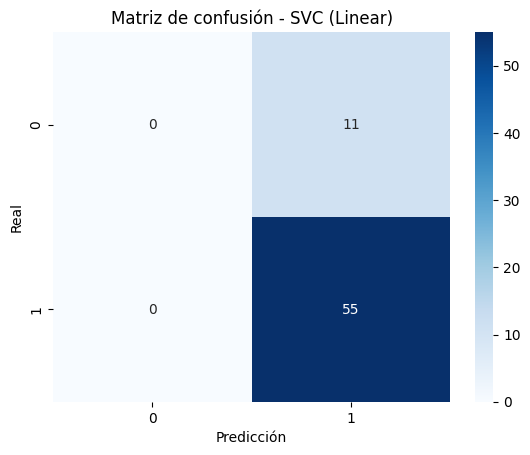


GaussianNB - Accuracy: 0.6061 | F1 Macro: 0.5196
              precision    recall  f1-score   support

         0.0       0.22      0.55      0.32        11
         1.0       0.87      0.62      0.72        55

    accuracy                           0.61        66
   macro avg       0.55      0.58      0.52        66
weighted avg       0.76      0.61      0.66        66



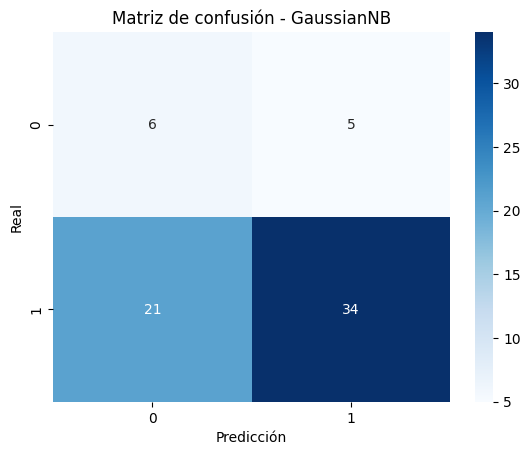

In [108]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, multi_class='multinomial', solver='lbfgs'),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC (Linear)": SVC(kernel='linear', probability=True, random_state=42),
    "GaussianNB": GaussianNB()
}
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train) # ENTRENAR
    y_pred = model.predict(X_test_scaled) # PREDICCION
    # EVALUAR MODELO
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    results[name] = {
        "model": model,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "y_pred": y_pred
    }
    print(f"\n{name} - Accuracy: {acc:.4f} | F1 Macro: {f1_macro:.4f}")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

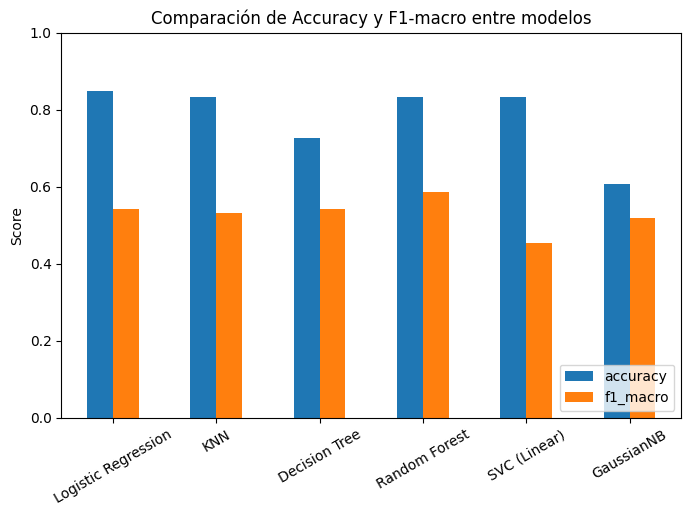

In [111]:
metricas = pd.DataFrame({
    'accuracy': {name: res['accuracy'] for name, res in results.items()},
    'f1_macro': {name: res['f1_macro'] for name, res in results.items()}
})

metricas.plot(kind='bar', figsize=(8,5))
plt.title('Comparación de Accuracy y F1-macro entre modelos')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.show()

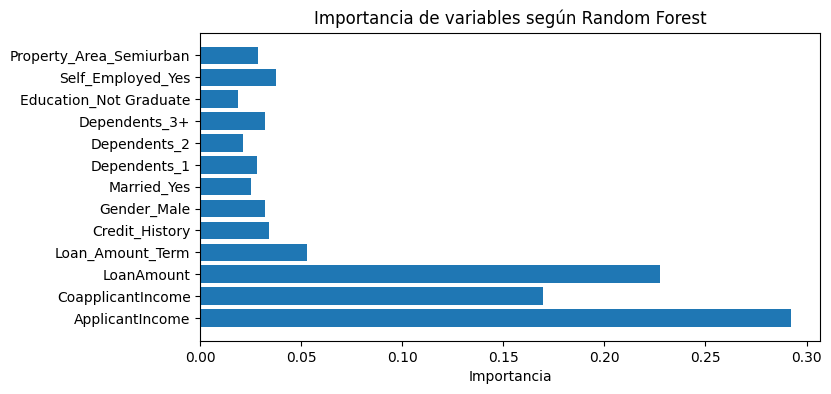

In [112]:
#Importancia de las variables para otorgar el credito.
importancias = results['Random Forest']['model'].feature_importances_
plt.figure(figsize=(8,4))
plt.barh(df.columns[:-1], importancias)
plt.title('Importancia de variables según Random Forest')
plt.xlabel('Importancia')
plt.show()

¿Qué tan bueno es el modelo?
 En los modelos que se puede observar un accuracy con 83 y 85% podriamos evidenciar un buen ejercicio de desempeño; sin embargo tambien encontramos algunos modelos por debajo de 70% lo que indica que podriamos mejorar la calidad de información

¿Qué variable parece influir más en la predicción?

La variable que mas influye en la predicción es ApplicantIncome; que vendria siendo como el ingreso de quien solicita el crédito


¿Qué mejorarías si tuvieras más tiempo?

Sin duda alguna la calidad de la información para entrenar mejor los modelos;